In [37]:
#Importation of all the necessary packages
import os
import numpy as np
from matplotlib import pylab as plt
import bempp_cl.api as bempp            
import gmsh
from IPython import get_ipython
import matplotlib
from bempp_cl.core import opencl_kernels
import bempp_cl.api as bempp

In [38]:
#Function used to empty the RAM
os.environ['PYOPENCL_COMPILER_OUTPUT']='1'

#Pour redémarrer le kernel
#Ctrl + Shift + P
#Jupyter: Restart Kernel

In [39]:
#Definition of classes to describe the geometry
class Cylinder:
    def __init__(self, length, radius, coord_x, coord_y, coord_z):
        self.length = length
        self.radius = radius
        self.coord_x = coord_x
        self.coord_y = coord_y
        self.coord_z = coord_z


    def ajouter(self):
        cyl_tag = gmsh.model.occ.addCylinder(self.coord_x, self.coord_y, self.coord_z, 0, 0, self.length, self.radius)
        cyl_surf = gmsh.model.occ.get_surface_loops(cyl_tag)[1][0]

        return cyl_tag, cyl_surf



class Aperture: 
    def __init__(self, radius_ext, radius_in, thickness, coord_x, coord_y, coord_z):
        self.radius_ext = radius_ext
        self.radius_in = radius_in
        self.thickness = thickness
        self.coord_x = coord_x
        self.coord_y = coord_y
        self.coord_z = coord_z


    def ajouter (self):
        aperture_out = gmsh.model.occ.addCylinder(self.coord_x, self.coord_y, self.coord_z, 0, 0, self.thickness, self.radius_ext)
        aperture_in = gmsh.model.occ.addCylinder(self.coord_x, self.coord_y, self.coord_z, 0, 0, self.thickness, self.radius_in)
        apert_vol , _=  gmsh.model.occ.cut([(3,aperture_out)],[(3,aperture_in)])
        apert_tag=apert_vol[0][1]
        apert_surf = gmsh.model.occ.get_surface_loops(apert_tag)[1][0]

        return apert_tag, apert_surf

class Dimensions: 
    def __init__(self, 
                dist_apert_quad,
                radius_apert, thickness_apert, 
                length_cylinder, 
                radius_axis):
        self.dist_apert_quad = dist_apert_quad

        self.radius_apert = radius_apert
        self.thickness_apert = thickness_apert

        self.length_cylinder = length_cylinder

        self.radius_axis = radius_axis
            
            
    def total_length(self):
        return 2*self.dist_apert_quad + 2*self.thickness_apert + self.length_cylinder
    

    def coord_cylinder(self):
        x_or_y = 2*self.radius_axis
        z = self.thickness_apert + self.dist_apert_quad

        return x_or_y, z
    

    def coord_apert(self):
        z1 = 0
        z2 = self.thickness_apert + 2*self.dist_apert_quad + self.length_cylinder

        return z1, z2
    

In [40]:
#Definition of the geometry 

#Settings of the dimensions of the geometry 
dimensions = Dimensions(4, 15, 2, 14, 3.49)
''' 
#1 - Distance between the sield ant the aperture 
#2 - Distance between the aperture and the cylinders (d)
#3 - Exterior radius of the shield 
#4 - Inside radius of the shield 
#5 - Thickness of the shield
#6 - Radius of the aperture 
#7 - Thickness of the aperture 
#8 - Length of the cylinder (l)
#9 - Radius of the elements around the axis (a)
'''

def generate_mesh(): 

    gmsh.initialize()
    gmsh.clear()
    gmsh.model.add("Quadrupole lens")

    cylinder1 = Cylinder(dimensions.length_cylinder, dimensions.radius_axis, dimensions.coord_cylinder()[0], 0, dimensions.coord_cylinder()[1])
    cylinder1 = Cylinder.ajouter(cylinder1)

    cylinder2 = Cylinder(dimensions.length_cylinder, dimensions.radius_axis, -dimensions.coord_cylinder()[0], 0, dimensions.coord_cylinder()[1])
    cylinder2 = Cylinder.ajouter(cylinder2)

    cylinder3 = Cylinder(dimensions.length_cylinder, dimensions.radius_axis, 0, dimensions.coord_cylinder()[0], dimensions.coord_cylinder()[1])
    cylinder3 = Cylinder.ajouter(cylinder3)

    cylinder4 = Cylinder(dimensions.length_cylinder, dimensions.radius_axis, 0, -dimensions.coord_cylinder()[0], dimensions.coord_cylinder()[1])
    cylinder4 = Cylinder.ajouter(cylinder4)


    aperture1 = Aperture(dimensions.radius_apert, dimensions.radius_axis, dimensions.thickness_apert, 0, 0, dimensions.coord_apert()[0])
    aperture1 = Aperture.ajouter(aperture1)

    aperture2 = Aperture(dimensions.radius_apert, dimensions.radius_axis, dimensions.thickness_apert, 0, 0, dimensions.coord_apert()[1])
    aperture2 = Aperture.ajouter(aperture2)

    #Creation of the mesh
    gmsh.model.occ.synchronize()

    #Outwards orientation of the surfaces' normals
    gmsh.model.mesh.setOutwardOrientation(aperture1[0])
    gmsh.model.mesh.setOutwardOrientation(aperture2[0])
    gmsh.model.mesh.setOutwardOrientation(cylinder1[0])
    gmsh.model.mesh.setOutwardOrientation(cylinder2[0])
    gmsh.model.mesh.setOutwardOrientation(cylinder3[0])
    gmsh.model.mesh.setOutwardOrientation(cylinder4[0])

    #Adds surfaces on top of the volumes created 
    group_id_apert1 = gmsh.model.addPhysicalGroup(2,aperture1[1])
    group_id_apert2 = gmsh.model.addPhysicalGroup(2,aperture2[1])
    group_id_cyl1 = gmsh.model.addPhysicalGroup(2,cylinder1[1])
    group_id_cyl2 = gmsh.model.addPhysicalGroup(2,cylinder2[1])
    group_id_cyl3 = gmsh.model.addPhysicalGroup(2,cylinder3[1])
    group_id_cyl4 = gmsh.model.addPhysicalGroup(2,cylinder4[1])

    #Size of the mesh
    #ATTENTION, MeshSizeMin and MeshSizeMax need to be equal
    gmsh.option.set_number('Mesh.MeshSizeMin', 1.5)
    gmsh.option.set_number('Mesh.MeshSizeMax', 1.5)

    gmsh.model.mesh.generate(2)

    #Creates a file .msh
    gmsh.write("mesh_quadrupole.msh")

    #Opens a terminal to see the geometry (il faut préalablement installer une extension dans Visual studio code intitulé "STL Viewer")
    gmsh.fltk.run()

    gmsh.finalize()

    return group_id_apert1, group_id_apert2, group_id_cyl1, group_id_cyl2, group_id_cyl3, group_id_cyl4

In [41]:
#Definition of classes to describe the potential of the geometry

class Potentials:
    def __init__(self, pot_electrode, pot_apert1, pot_apert2):
        self.pot_electrode = pot_electrode
        self.pot_apert1 = pot_apert1
        self.pot_apert2 = pot_apert2

In [42]:
#Potential extraction

#Settings of the potentials

#On prend Vq2 sur le papier d'okayama
Va=1
Vq2=-0.0299087*Va
Vapert1=-0.18808*Va
Vapert2=0.10918*Va
potentials = Potentials(Vq2, Vapert1, Vapert2)


def calculate_field(elec_id):
    plt.clf()

    #Importation of the mesh
    grid= bempp.import_grid("mesh_quadrupole.msh")

    ##Definition of different spaces
    dp0_space = bempp.function_space(grid, "DP", 0)
    p1_space = bempp.function_space(grid, "P", 1)

    #Definition of different operators (single layer, double layer and identity)
    identity = bempp.operators.boundary.sparse.identity(p1_space, p1_space, dp0_space)
    dlp = bempp.operators.boundary.laplace.double_layer(p1_space, p1_space, dp0_space)
    slp = bempp.operators.boundary.laplace.single_layer(dp0_space, p1_space, dp0_space)

    #Settings of the potentials
    pot_apert1 = potentials.pot_apert1
    pot_apert2 = potentials.pot_apert2
    pot_electrode = potentials.pot_electrode

    @bempp.real_callable
    #Setting of the potential on the different elements of the geometry
    def dirichlet_data(x, n, domain_index, result):
        if domain_index == elec_id[0]: #potential of the 1st aperture
            result[0]=pot_apert1
            
        elif domain_index == elec_id[1]: #potential of the 2nd aperture
            result[0]=pot_apert2
        
        elif domain_index == elec_id[2]: #potential of the 1st electrode
            result[0]=pot_electrode

        elif domain_index == elec_id[3]: #potential of the 2nd electrode
            result[0]=pot_electrode

        elif domain_index == elec_id[4]: #potential of the 3rd electrode
            result[0]=-pot_electrode

        elif domain_index == elec_id[5]: #potential of the 4th electrode
            result[0]=-pot_electrode

    dirichlet_fun = bempp.GridFunction(p1_space, fun=dirichlet_data) 
    
    #bempp.PLOT_BACKEND = "paraview"
    #Prints the potential associated to the geometry 
    #dirichlet_fun.plot() 

    #Sum of the right part of the integral 
    rhs = (-0.5 * identity + dlp) * dirichlet_fun

    #Resolution of the linear system
    neumann_fun, _ = bempp.linalg.cg(slp, rhs, tol=1e-8) #1e-5 à tester

    #Creation of the tracing of the solution
    n_grid_points = 100
    points = np.stack((np.zeros(n_grid_points), np.zeros(n_grid_points), (np.linspace(0, dimensions.total_length(), n_grid_points)))) #x=y=0 and z changes from 0 to elec_id[7][11]=total_length

    #Green's representation
    slp_pot = bempp.operators.potential.laplace.single_layer(dp0_space, points) #total matrix
    u_evaluated = -slp_pot * neumann_fun 

    #Field 
    E = slp_pot = bempp.operators.potential.laplace.single_layer_gradient(dp0_space, points, device_interface="opencl")
    E_eval = -E * neumann_fun

    #Field's 2nd derivative
    D2 = bempp.operators.potential.laplace.single_layer_2nd_deriv(dp0_space,points, device_interface="opencl")
    D2_eval = D2 * neumann_fun
  
    #Field's 3rd derivative
    D3 = bempp.operators.potential.laplace.single_layer_3rd_deriv(dp0_space, points, device_interface="opencl")
    D3_eval = D3 * neumann_fun

    #Field's 4th derivative
    D4 = bempp.operators.potential.laplace.single_layer_4th_deriv(dp0_space, points, device_interface="opencl")
    D4_eval = D4 * neumann_fun

    try:
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython is not None:
            ipython.run_line_magic("matplotlib", "inline")
            ipython = True

    except NameError:
        ipython = False

    #Printing of the solution --> printing of the potential along the z axis ~ 0V
    plt.plot(points[2], u_evaluated[0])
    plt.title("Potentiel du quadrupole d'Okayama le long de l'axe Z")
    plt.xlabel("Position en z (mm)")
    plt.ylabel("Potentiel (V)")
    plt.show()

    savefile="potentiel_quadrupole_sans_shield"
    
    #Creation of a .npz file with the extracted potential
    if "savefile" is not None:
        np.savez_compressed(
    savefile,
    points=points,
    potential=u_evaluated,
    group_id_ap1=elec_id[0],
    group_id_ap2=elec_id[1],
    group_id_cyl1=elec_id[2],
    group_id_cyl2=elec_id[3],
    group_id_cyl3=elec_id[4],
    group_id_cyl4=elec_id[5],
    dimensions=np.array((dimensions.dist_apert_quad, 
    dimensions.radius_apert, dimensions.thickness_apert, dimensions.length_cylinder, dimensions.radius_axis, dimensions.total_length(), dimensions.coord_cylinder()[0], 
    dimensions.coord_cylinder()[1], dimensions.coord_apert()[0], dimensions.coord_apert()[1])),
    potentials=(potentials.pot_electrode, potentials.pot_apert1, potentials.pot_apert2),
    E_eval=E_eval,
    D2_eval=D2_eval,
    D3_eval=D3_eval,
    D4_eval=D4_eval)
                            
    print(f"Saved potential to {savefile}.npz")
    
    return (u_evaluated[0])


<>:110: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
C:\Users\zoeno\AppData\Local\Temp\ipykernel_9848\1652260637.py:110: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if "savefile" is not None:


c:\Users\zoeno\venv\bempp\Lib\site-packages\pyopencl\cache.py:496: CompilerWarning: Built kernel retrieved from cache. Original from-source build had warnings:
Build on <pyopencl.Device 'AMD Ryzen 5 5500U with Radeon Graphics' on 'Intel(R) OpenCL' at 0x116cd5ab310> succeeded, but said:

Compilation started
Compilation done
Linking started
Linking done
Device build started
Options used by backend compiler: -D NUMBER_OF_QUAD_POINTS=6 -D TEST=p0_discontinuous -D TRIAL=p1_discontinuous -D TRIAL_NUMBER_OF_ELEMENTS=5548 -D TEST_NUMBER_OF_ELEMENTS=5548 -D NUMBER_OF_TEST_SHAPE_FUNCTIONS=1 -D NUMBER_OF_TRIAL_SHAPE_FUNCTIONS=3 -D KERNEL_FUNCTION=laplace_double_layer -D VEC_LENGTH=4 -D VEC_STRING=vec4 -I C:\Users\zoeno\venv\bempp\Lib\site-packages\bempp_cl\core\sources\include -DPRECISION=1 -I c:\Users\zoeno\venv\bempp\Lib\site-packages\pyopencl\cl
Device build done
remark: <unknown>:0:0: 878 instructions in function
Kernel "kernel_function" was not vectorized
Done.
  _create_built_program_from_s

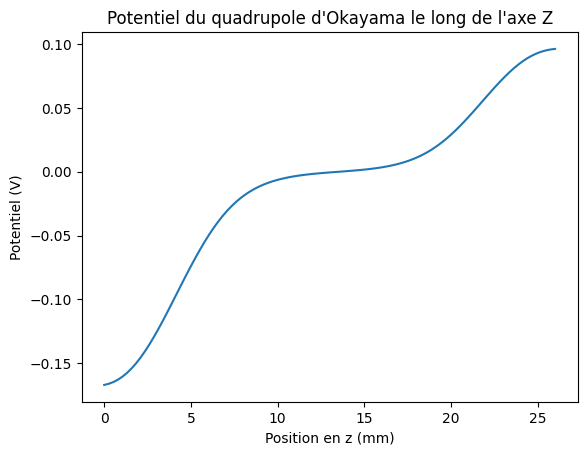

Saved potential to potentiel_quadrupole_sans_shield.npz


array([-1.66933444e-01, -1.66046214e-01, -1.64696757e-01, -1.62848663e-01,
       -1.60472040e-01, -1.57545800e-01, -1.54059787e-01, -1.50016463e-01,
       -1.45431890e-01, -1.40335771e-01, -1.34770527e-01, -1.28789527e-01,
       -1.22454768e-01, -1.15834368e-01, -1.09000179e-01, -1.02025727e-01,
       -9.49845307e-02, -8.79487588e-02, -8.09880837e-02, -7.41685944e-02,
       -6.75516550e-02, -6.11926616e-02, -5.51397401e-02, -4.94325038e-02,
       -4.41010442e-02, -3.91653347e-02, -3.46351755e-02, -3.05107251e-02,
       -2.67835605e-02, -2.34381271e-02, -2.04533948e-02, -1.78045357e-02,
       -1.54644760e-02, -1.34052216e-02, -1.15989143e-02, -1.00186146e-02,
       -8.63883720e-03, -7.43587742e-03, -6.38797485e-03, -5.47535378e-03,
       -4.68017746e-03, -3.98644459e-03, -3.37985025e-03, -2.84762712e-03,
       -2.37837818e-03, -1.96190814e-03, -1.58905822e-03, -1.25154665e-03,
       -9.41816197e-04, -6.52888828e-04, -3.78226925e-04, -1.11600310e-04,
        1.53042170e-04,  

In [43]:
elec_id = generate_mesh()
calculate_field(elec_id)

In [44]:
#File importation
data = np.load(r"C:\Users\zoeno\OneDrive\Documents\INSA\4GP\Projet multi\Code\Python\Versions récentes\potentiel_quadrupole_sans_shield.npz")

In [45]:
#Creation of a class to download all the necessary datas
"""
class Datas:
    def __init__(self, z_axis, potential, E_eval, D2_eval, D3_eval, D4_eval, points, Va, Vq, dimensions):
        self.z_axis = z_axis
        self.potential = potential
        self.E_eval = E_eval
        self.D2_eval = D2_eval
        self.D3_eval = D3_eval
        self.D4_eval = D4_eval
        self.points = points
        self.Va = Va
        self.Vq = Vq
        self.dimensions = dimensions

    def download(self):
        self.z_axis = data["points"][2] 
        self.potential = data["potential"]
        self.E_eval = data["E_eval"]
        self.D2_eval = data["D2_eval"]
        self.D3_eval = data["D3_eval"]
        self.
"""   


'\nclass Datas:\n    def __init__(self, z_axis, potential, E_eval, D2_eval, D3_eval, D4_eval, points, Va, Vq, dimensions):\n        self.z_axis = z_axis\n        self.potential = potential\n        self.E_eval = E_eval\n        self.D2_eval = D2_eval\n        self.D3_eval = D3_eval\n        self.D4_eval = D4_eval\n        self.points = points\n        self.Va = Va\n        self.Vq = Vq\n        self.dimensions = dimensions\n\n    def download(self):\n        self.z_axis = data["points"][2] \n        self.potential = data["potential"]\n        self.E_eval = data["E_eval"]\n        self.D2_eval = data["D2_eval"]\n        self.D3_eval = data["D3_eval"]\n        self.\n'

In [46]:
#Récupération des données nécessaire dans le fichier 
z_axis = data["points"][2] 
potential = data["potential"]
E_eval = data["E_eval"]
D2_eval = data["D2_eval"]
D3_eval = data["D3_eval"]
D4_eval = data["D4_eval"]
points = data["points"]
Va = data["group_id_ap1"]
Vq = data["group_id_cyl1"]
dimension = data["dimensions"]

In [47]:
#Creation of a class that describes characteristic values for the fit function
class Fit_constants:
    def __init__(self, a0, b0, b2, a4, b41, b42, z0, a):
        self.a0 = a0
        self.b0 = b0
        self.b2 = b2
        self.a4 = a4
        self.b41 = b41
        self.b42 = b42
        self.z0 = z0
        self.a = a

In [71]:
fit_constants = Fit_constants(0.80751, 5.08, 4.54, 0.03891461, 3.113, 2.015, 2.4, 3.493e-1 )

#Fonction that calculates the composants of the potential decomposition
def Decomposition (D0, D1, D2, D3, D4):

    Phi0_maj = -D0 # potentiel monopolaire sur l’axe
    Phi1_maj = (1/dimensions.radius_axis)*(D1[0])
    Phi2_maj = (1/dimensions.radius_axis**2) * (1/8)*(D2[0] - D2[3])
    Phi3_maj = (1/dimensions.radius_axis**3) * (1/24) * (D3[0] - 3*D3[3])
    Phi4_maj = (1/dimensions.radius_axis**4) * (10/192)* (D4[0] + D4[10] - 6*D4[3])

    #Phi2_max = np.max(np.abs(Phi2_maj))
    moit = (len(Phi0_maj))//2
    fin = len(Phi0_maj)
    Phi0_maj_half = Phi0_maj[moit:fin] # potentiel monopolaire sur l’axe
    Phi1_maj_half = Phi1_maj[moit:fin]
    Phi2_maj_half = Phi2_maj[moit:fin]
    Phi3_maj_half = Phi3_maj[moit:fin]
    Phi4_maj_half = Phi4_maj[moit:fin]
    
    return Phi0_maj_half, Phi1_maj_half, Phi2_maj_half, Phi3_maj_half, Phi4_maj_half

In [72]:
#Fonction that calculates the fit functions
def Fonctions_fit(z_axis, offset_ko, offset_k2, offset_k4):

    z0_1 = z_axis - offset_ko
    k0_1 = fit_constants.a0 * np.exp(-(z_axis**2) / (fit_constants.b0**2))

    #z0_2 = z_axis - (dimension[11] - offset_ko)
    #k0_2 = fit_constants.a0 * np.exp(-(z0_2**2) / (fit_constants.b0**2))

    z2 = z_axis - offset_k2
    k2 = np.where( np.abs(z_axis) <= fit_constants.z0, 1.0, np.exp(-(np.abs(z_axis) - fit_constants.z0)**2 / (fit_constants.b2**2)))

    z4_1 = z_axis - offset_k4
    k4_1 = np.where(z_axis <= 0, fit_constants.a4 / (1 + (z_axis**2 / fit_constants.b41**2)**2), fit_constants.a4 * np.exp(-(z_axis**2) / (fit_constants.b42**2)))

    #z4_2 = z_axis - (dimension[11] - offset_k4)
    #k4_2 = np.where(z4_2 <= 0, fit_constants.a4 / (1 + (z4_2**2 / fit_constants.b41**2)**2), fit_constants.a4 * np.exp(-(z4_2**2) / (fit_constants.b42**2)))

    return k0_1, k2, k4_1

In [73]:
Phi0_maj, Phi1_maj, Phi2_maj, Phi3_maj, Phi4_maj = Decomposition (potential[0], E_eval, D2_eval, D3_eval, D4_eval)
k0_1, k2, k4_1 = Fonctions_fit (z_axis, 1, 13, 7.5)

In [74]:
#Creation of a function to trace the geometry on the graph
def trace_geo(ax):

    start_apert1 =0
    end_apert1 = start_apert1 + dimensions.thickness_apert

    start_cyl = end_apert1 + dimensions.dist_apert_quad
    end_cyl = start_cyl + dimensions.length_cylinder

    start_apert2 = end_cyl + dimensions.dist_apert_quad
    end_apert2 = start_apert2 + dimensions.thickness_apert

    ax.axvspan(start_apert1, end_apert1, color='blue', alpha=0.3, label='Aperture')
    ax.axvspan(start_cyl, end_cyl, color='green', alpha=0.3, label='Electrodes')
    ax.axvspan(start_apert2, end_apert2, color='blue', alpha=0.3)

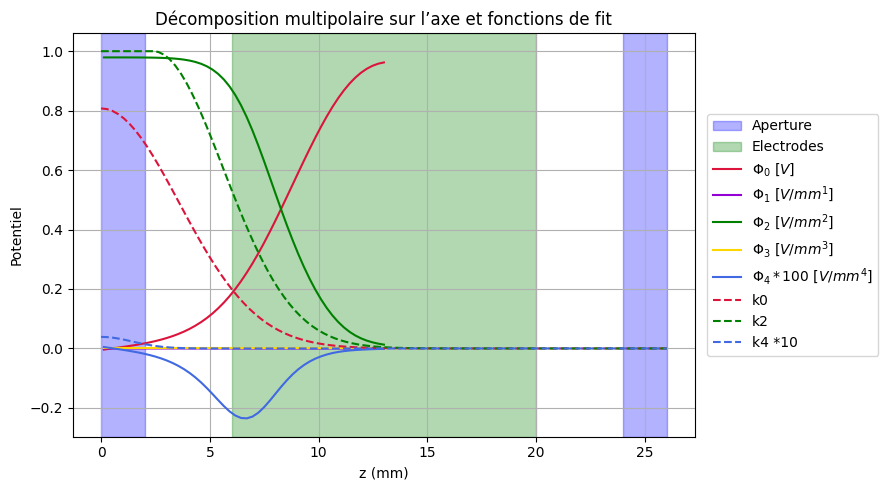

In [82]:
fig, ax = plt.subplots(figsize=(9, 5))
trace_geo(ax)

moit = (len(z_axis))//2
fin = len(z_axis)

#Printing of the different composants of the potential
plt.plot(z_axis[moit:fin]-dimensions.total_length()//2, -Phi0_maj*10, label=r'$\Phi_0 $ $[V]$', color='crimson')
plt.plot(z_axis[moit:fin]-dimensions.total_length()//2, Phi1_maj*10, label=r'$\Phi_1$ $[V/mm^1]$', color='darkviolet')
plt.plot(z_axis[moit:fin]-dimensions.total_length()//2, -Phi2_maj*10000, label=r'$\Phi_2$ $[V/mm^2]$', color='green')
plt.plot(z_axis[moit:fin]-dimensions.total_length()//2, Phi3_maj*10, label=r'$\Phi_3$ $[V/mm^3]$', color='gold')
plt.plot(z_axis[moit:fin]-dimensions.total_length()//2, Phi4_maj*100000, label=r'$\Phi_4 *100$ $[V/mm^4]$', color='royalblue')
plt.plot(z_axis, k0_1, label=r'k0', color='crimson', linestyle='dashed')
#plt.plot(z_axis, k0_2, color='crimson', linestyle='dashed')
plt.plot(z_axis, k2, label=r'k2', color='green', linestyle='dashed')
plt.plot(z_axis, k4_1, label=r'k4 *10', color='royalblue', linestyle='dashed')
#plt.plot(z_axis, k4_2, color='royalblue', linestyle='dashed')
plt.xlabel("z (mm)")
plt.ylabel("Potentiel")
plt.title("Décomposition multipolaire sur l’axe et fonctions de fit")
plt.grid()
plt.legend()
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
plt.tight_layout()
plt.show()